<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%B0%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_13_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Створити агентну модель на основі моделі Леотьєва. Чуркін дмитро ФІТ 3-15

In [2]:
!pip install mesa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 4.8 MB/s eta 0:00:00


Крок 0
Крок 1
Крок 2
Крок 3
Крок 4
Крок 5
Крок 6
Крок 7
Крок 8
Крок 9
Крок 10
Крок 11
Крок 12
Крок 13
Крок 14
Крок 15
Крок 16
Крок 17
Крок 18
Крок 19


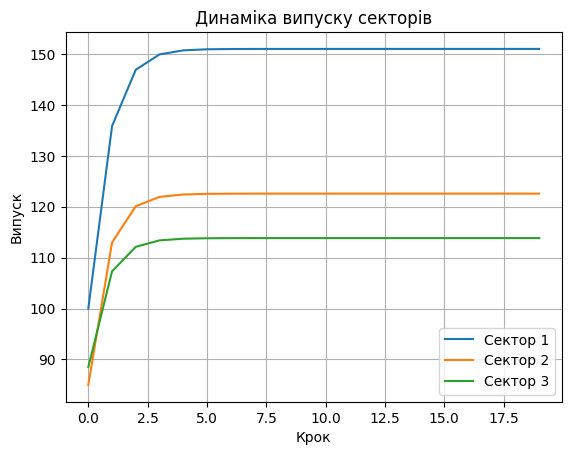

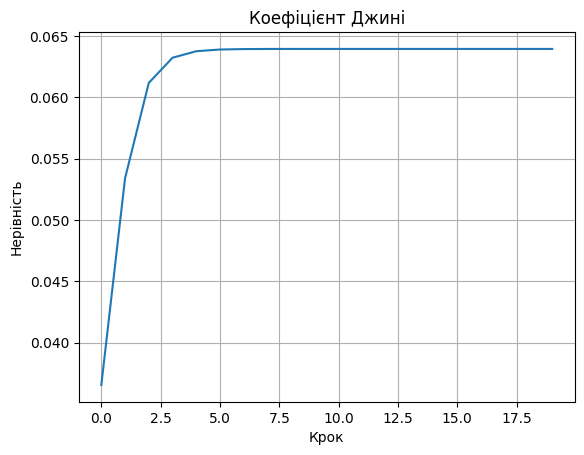


--- ЕКСПЕРИМЕНТ: +20% до сектору 1 ---
Крок 0
Крок 1
Крок 2
Крок 3
Крок 4
Крок 5
Крок 6
Крок 7
Крок 8
Крок 9
Крок 10
Крок 11
Крок 12
Крок 13
Крок 14
Крок 15
Крок 16
Крок 17
Крок 18
Крок 19


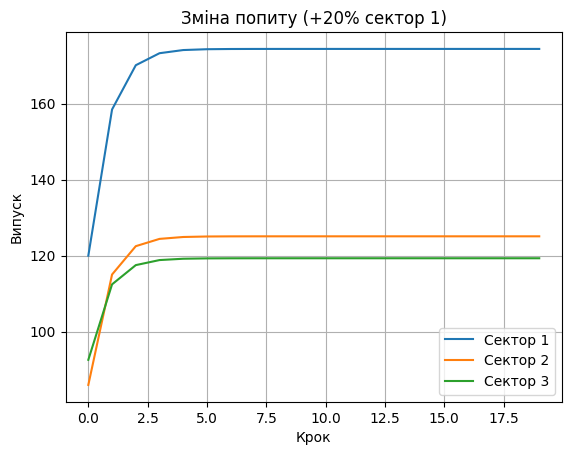


--- ЕКСПЕРИМЕНТ: відключення сектору 2 ---
Крок 0
Крок 1
Крок 2
Крок 3
Крок 4
Крок 5
Крок 6
Крок 7
Крок 8
Крок 9
Крок 10
Крок 11
Крок 12
Крок 13
Крок 14
Крок 15
Крок 16
Крок 17
Крок 18
Крок 19


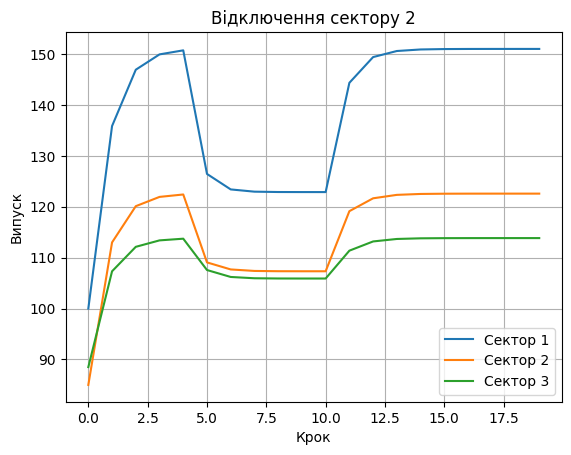

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mesa

# ===== ФУНКЦІЯ ДЖИНІ =====
def compute_gini(outputs):
    n = len(outputs)
    mean = np.mean(outputs)
    if mean == 0:
        return 0
    diff_sum = 0
    for i in outputs:
        for j in outputs:
            diff_sum += abs(i - j)
    return diff_sum / (2 * n**2 * mean)


# ===== АГЕНТ =====
class IndustryAgent(mesa.Agent):
    def __init__(self, model, sector_id, a_row, final_demand):
        super().__init__(model)
        self.sector_id = sector_id
        self.a_row = a_row
        self.final_demand = final_demand
        self.output = 0

    def step(self):
        prev_outputs = self.model.get_outputs()
        intermediate = np.dot(self.a_row, prev_outputs)
        self.output = self.final_demand + intermediate
        self.model.record_output(self.sector_id, self.output)


# ===== МОДЕЛЬ =====
class InputOutputModel(mesa.Model):
    def __init__(self, A_matrix, final_demand, steps=20):
        super().__init__()
        self.A = A_matrix
        self.D = final_demand
        self.steps = steps
        self.num_sectors = len(final_demand)
        self.current_step = 0

        # агенти
        self.agents_list = []
        for i in range(self.num_sectors):
            agent = IndustryAgent(self, i, A_matrix[i], final_demand[i])
            self.agents_list.append(agent)

        # таблиця результатів
        self.outputs = pd.DataFrame(
            index=range(steps),
            columns=[f"Сектор {i+1}" for i in range(self.num_sectors)]
        )

        self.gini_history = []

    def get_outputs(self):
        return np.array([agent.output for agent in self.agents_list])

    def record_output(self, sector_id, output):
        self.outputs.iloc[self.current_step, sector_id] = output

    def step(self):
        for agent in self.agents_list:
            agent.step()

        # коеф. Джині
        gini = compute_gini(self.get_outputs())
        self.gini_history.append(gini)

        self.current_step += 1

    def run_model(self):
        for i in range(self.steps):
            print(f"Крок {i}")
            self.step()


# ===== ДАНІ =====
A = np.array([
    [0.1, 0.2, 0.1],
    [0.05, 0.1, 0.2],
    [0.2, 0.1, 0.1]
])

D = np.array([100, 80, 60])


# ===== ЗАПУСК =====
model = InputOutputModel(A, D, steps=20)
model.run_model()


# ===== ГРАФІКИ =====
# 1. Випуск секторів
for col in model.outputs.columns:
    plt.plot(model.outputs.index, model.outputs[col], label=col)

plt.legend()
plt.title("Динаміка випуску секторів")
plt.xlabel("Крок")
plt.ylabel("Випуск")
plt.grid()
plt.show()


# 2. Джині
plt.plot(model.gini_history)
plt.title("Коефіцієнт Джині")
plt.xlabel("Крок")
plt.ylabel("Нерівність")
plt.grid()
plt.show()


# ===== ЕКСПЕРИМЕНТ (зміна попиту) =====
print("\n--- ЕКСПЕРИМЕНТ: +20% до сектору 1 ---")
D_new = D.copy()
D_new[0] *= 1.2

model2 = InputOutputModel(A, D_new, steps=20)
model2.run_model()

for col in model2.outputs.columns:
    plt.plot(model2.outputs.index, model2.outputs[col], label=col)

plt.legend()
plt.title("Зміна попиту (+20% сектор 1)")
plt.xlabel("Крок")
plt.ylabel("Випуск")
plt.grid()
plt.show()


# ===== АВАРІЯ СЕКТОРА =====
print("\n--- ЕКСПЕРИМЕНТ: відключення сектору 2 ---")

class ShockModel(InputOutputModel):
    def step(self):
        if 5 <= self.current_step <= 10:
            self.agents_list[1].output = 0
        super().step()


model3 = ShockModel(A, D, steps=20)
model3.run_model()

for col in model3.outputs.columns:
    plt.plot(model3.outputs.index, model3.outputs[col], label=col)

plt.legend()
plt.title("Відключення сектору 2")
plt.xlabel("Крок")
plt.ylabel("Випуск")
plt.grid()
plt.show()